# Tier 1 · Notebook 9 — Regularization & Training Dynamics

> **Goal:** the practical knobs that decide whether a training run *works* — **learning-rate schedules** (warmup + cosine), **label smoothing**, **gradient clipping**, and **early stopping** — each derived and shown *changing a real curve*. These aren't optional polish; on modern models the difference between "diverges / mediocre" and "state-of-the-art" is often exactly these settings.

We already met dropout and weight decay (NB6) and the optimizers themselves (NB4). This notebook is about *how you drive* the optimizer over the course of training — the schedule and stabilizers that every serious training recipe (including every LLM) relies on.


In [1]:
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# a small MNIST subset for fast, repeatable experiments
from torchvision import datasets, transforms
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
full = datasets.MNIST("../data", train=True, download=True, transform=tf)
test = datasets.MNIST("../data", train=False, download=True, transform=tf)
Xtr = full.data[:10000].float().reshape(-1,784).to(device); Xtr = (Xtr/255-0.1307)/0.3081
ytr = full.targets[:10000].to(device)
Xva = full.data[10000:12000].float().reshape(-1,784).to(device); Xva = (Xva/255-0.1307)/0.3081
yva = full.targets[10000:12000].to(device)
print("train", Xtr.shape, "val", Xva.shape)


device: cuda


train torch.Size([10000, 784]) val torch.Size([2000, 784])


## 1. Learning-rate schedules — the shape matters

A constant learning rate is rarely optimal. You want it **large early** (to move fast across the loss landscape) and **small late** (to settle precisely into a minimum without bouncing). Three standard shapes, plus the one everyone actually uses:
- **Step decay:** drop the LR by 10× at fixed milestones (old-school, still common in vision).
- **Cosine decay:** smoothly anneal from max to ~0 following a cosine curve — the modern default.
- **Warmup:** *ramp up* linearly for the first few hundred steps before decaying. Adaptive optimizers (Adam) have unreliable variance estimates early (recall NB4's bias-correction warm-up), and big models with big LRs can diverge in the first few steps — warmup avoids that. **Every large transformer uses linear-warmup + cosine-decay.**

Let's just *plot the schedules* first (no training) so the shapes are concrete.


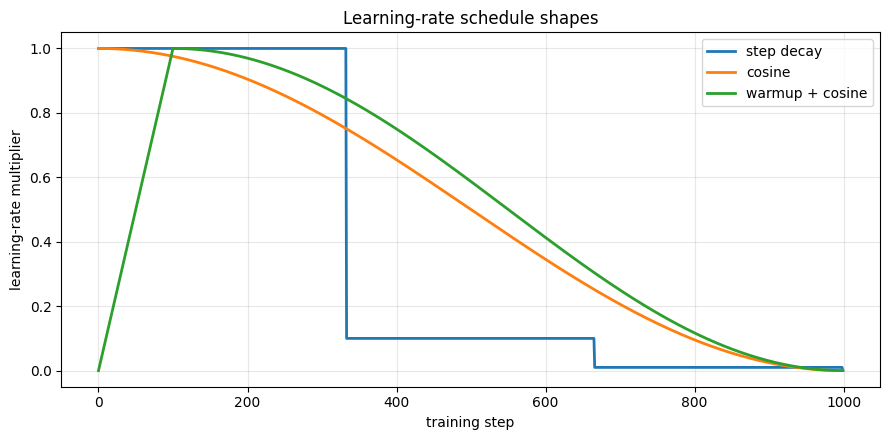

In [2]:
def cosine(step, total, base_lr):        return 0.5*base_lr*(1+np.cos(np.pi*step/total))
def warmup_cosine(step, total, base_lr, warm):
    if step < warm: return base_lr*step/warm
    return 0.5*base_lr*(1+np.cos(np.pi*(step-warm)/(total-warm)))
def step_decay(step, total, base_lr):
    return base_lr*(0.1**(step//(total//3)))

T = 1000; base = 1.0
steps = np.arange(T)
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(steps, [step_decay(s,T,base) for s in steps], lw=2, label="step decay")
ax.plot(steps, [cosine(s,T,base) for s in steps], lw=2, label="cosine")
ax.plot(steps, [warmup_cosine(s,T,base,100) for s in steps], lw=2, label="warmup + cosine")
ax.set_title("Learning-rate schedule shapes")
ax.set_xlabel("training step"); ax.set_ylabel("learning-rate multiplier"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** The warmup+cosine curve (green) ramps up over the first 100 steps, peaks, then glides smoothly to ~0. That early ramp is the safety rail; the smooth decay is the "slow down to park" phase. Step decay (blue) is jerky by comparison — each cliff causes a sudden loss drop but can waste time at a too-high LR before each milestone. Now let's prove the schedule *matters* by training with each.


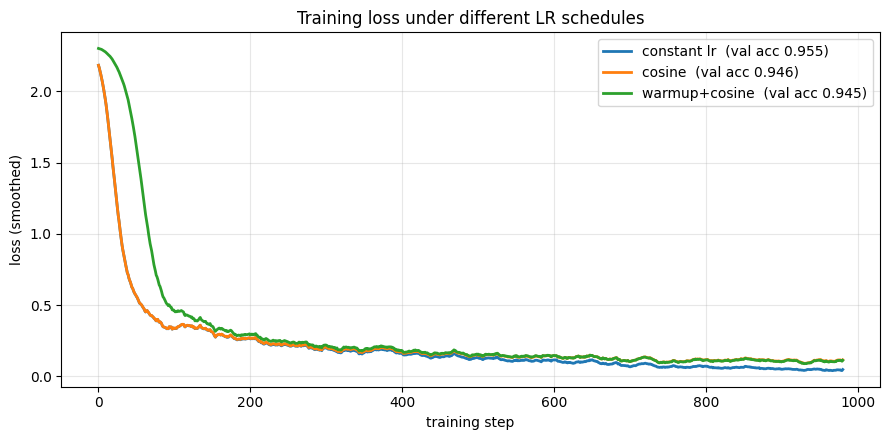

In [3]:
def make_model():
    torch.manual_seed(0)
    return nn.Sequential(nn.Linear(784,256), nn.ReLU(), nn.Linear(256,128), nn.ReLU(), nn.Linear(128,10)).to(device)

def train(schedule=None, base_lr=1e-2, steps=1000, bs=128, clip=None, label_smooth=0.0):
    model = make_model()
    opt = torch.optim.SGD(model.parameters(), lr=base_lr, momentum=0.9)
    lossf = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    hist = {"loss": [], "lr": [], "gnorm": []}
    for s in range(steps):
        if schedule:
            lr = schedule(s, steps, base_lr)
            for g in opt.param_groups: g["lr"] = lr
        else: lr = base_lr
        ix = torch.randint(0, len(Xtr), (bs,), device=device)
        loss = lossf(model(Xtr[ix]), ytr[ix])
        opt.zero_grad(); loss.backward()
        gnorm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters())).item()
        if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        hist["loss"].append(loss.item()); hist["lr"].append(lr); hist["gnorm"].append(gnorm)
    with torch.no_grad():
        acc = (model(Xva).argmax(1) == yva).float().mean().item()
    return hist, acc, model

runs = {
    "constant lr":     train(None, base_lr=1e-2),
    "cosine":          train(cosine, base_lr=1e-2),
    "warmup+cosine":   train(lambda s,t,b: warmup_cosine(s,t,b,100), base_lr=1e-2),
}
fig, ax = plt.subplots(figsize=(9,4.5))
for name,(h,acc,_) in runs.items():
    sm = np.convolve(h["loss"], np.ones(20)/20, mode="valid")   # smoothed loss
    ax.plot(sm, lw=2, label=f"{name}  (val acc {acc:.3f})")
ax.set_title("Training loss under different LR schedules")
ax.set_xlabel("training step"); ax.set_ylabel("loss (smoothed)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** The scheduled runs reach a **lower final loss and higher validation accuracy** than the constant-LR run, because they anneal the LR to settle into the minimum instead of bouncing around it at a fixed step size. Warmup+cosine typically edges out plain cosine and is smoother early. The effect is modest on this easy task but grows with model/data scale — for LLMs the schedule is not optional, it's part of the recipe that determines whether the run converges at all.


## 2. Label smoothing — stop the model being overconfident

Standard cross-entropy pushes the model to output probability **1.0** for the true class and **0** for the rest. To do that, the logits must go to $\pm\infty$ — the model becomes *overconfident* and poorly calibrated. **Label smoothing** softens the target: instead of a one-hot $[0,0,1,0,\dots]$, use
$$y^{LS}_k = (1-\varepsilon)\,\mathbb{1}[k=t] + \frac{\varepsilon}{K},$$
i.e. put $1-\varepsilon$ on the true class and spread $\varepsilon$ across all $K$ classes (e.g. $\varepsilon=0.1$). The model now aims for ~0.9 on the truth, not 1.0 — so it stops pushing logits to infinity, generalizes a bit better, and is better calibrated. Let's compare the confidence distributions.


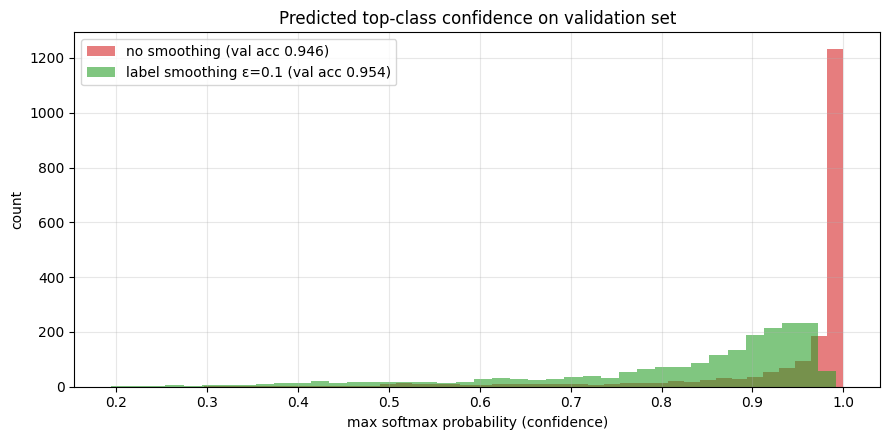

In [4]:
_, acc0, m0 = train(cosine, base_lr=1e-2, label_smooth=0.0)
_, acc1, m1 = train(cosine, base_lr=1e-2, label_smooth=0.1)
with torch.no_grad():
    conf0 = torch.softmax(m0(Xva), 1).max(1).values.cpu().numpy()   # top-class confidence
    conf1 = torch.softmax(m1(Xva), 1).max(1).values.cpu().numpy()

fig, ax = plt.subplots(figsize=(9,4.5))
ax.hist(conf0, bins=40, alpha=0.6, label=f"no smoothing (val acc {acc0:.3f})", color="tab:red")
ax.hist(conf1, bins=40, alpha=0.6, label=f"label smoothing ε=0.1 (val acc {acc1:.3f})", color="tab:green")
ax.set_title("Predicted top-class confidence on validation set")
ax.set_xlabel("max softmax probability (confidence)"); ax.set_ylabel("count"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** Without smoothing (red), the model piles almost everything at **confidence ≈ 1.0** — it's certain even when it's wrong (dangerous for anything that uses the probabilities downstream). With label smoothing (green), the confidence distribution is pulled back from the 1.0 wall — the model is appropriately *less* certain, which usually means better calibration and a small accuracy bump. Label smoothing is standard in image classification (Inception, ResNet recipes) and transformer training.


## 3. Gradient clipping — a seatbelt against loss spikes

Occasionally a bad minibatch (or an unlucky init, or a sharp region of the landscape) produces a **huge gradient** that, multiplied by the LR, throws the weights somewhere terrible — the loss spikes or NaNs. **Gradient clipping** rescales the gradient so its norm never exceeds a threshold $\tau$: if $\|g\| > \tau$, set $g \leftarrow \tau\, g/\|g\|$. Same direction, capped magnitude. It's essential for RNNs/transformers. Let's train at an aggressively high LR (where spikes happen) with and without clipping.


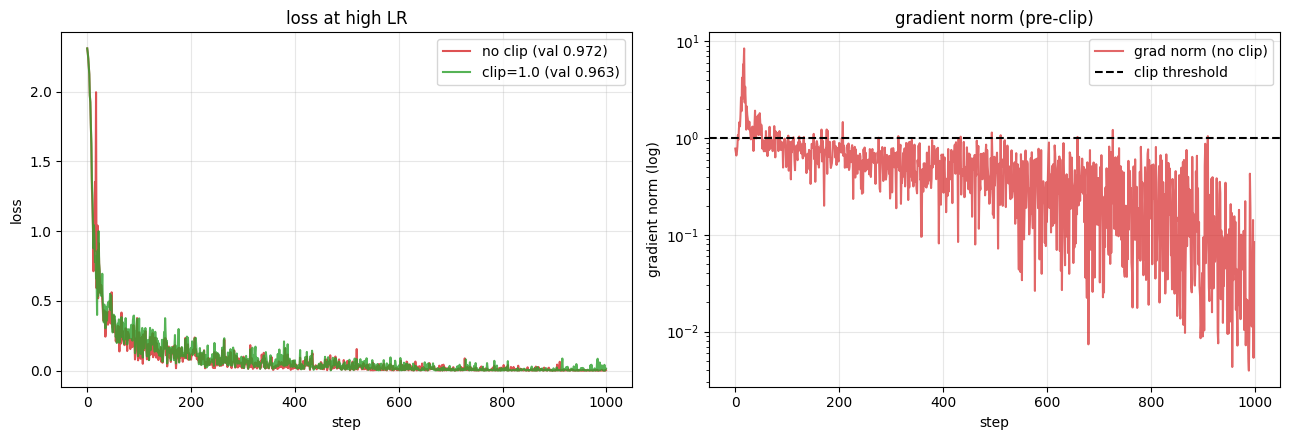

In [5]:
h_noclip, acc_nc, _ = train(None, base_lr=8e-2, steps=1000, clip=None)   # high LR, no clip
h_clip,   acc_c,  _ = train(None, base_lr=8e-2, steps=1000, clip=1.0)   # same, with clipping

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(h_noclip["loss"], color="tab:red", alpha=0.8, label=f"no clip (val {acc_nc:.3f})")
ax[0].plot(h_clip["loss"],  color="tab:green", alpha=0.8, label=f"clip=1.0 (val {acc_c:.3f})")
ax[0].set_title("loss at high LR"); ax[0].set_xlabel("step"); ax[0].set_ylabel("loss"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(h_noclip["gnorm"], color="tab:red", alpha=0.7, label="grad norm (no clip)")
ax[1].axhline(1.0, ls="--", color="k", label="clip threshold")
ax[1].set_yscale("log"); ax[1].set_title("gradient norm (pre-clip)")
ax[1].set_xlabel("step"); ax[1].set_ylabel("gradient norm (log)"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** Left: the unclipped run (red) shows loss **spikes** — moments where a large gradient kicked the model off course; the clipped run (green) is smoother and ends better. Right: the pre-clip gradient norm occasionally jumps far above the threshold (dashed line) — those are exactly the spikes clipping absorbs. Clipping doesn't change the *direction* of the update, only caps its size, so it's a cheap insurance policy. For transformer/LLM training, `clip_grad_norm_` at ~1.0 is standard.


## 4. Early stopping — quit at the validation minimum

From NB6: validation loss follows a U — it improves, bottoms out, then rises as the model overfits. **Early stopping** simply tracks the best validation score, keeps a snapshot of those weights, and if val hasn't improved for `patience` epochs, stops and restores the best snapshot. It's the simplest, most reliable regularizer — free generalization by not training too long. Let's train past the overfitting point and mark where early stopping would fire.


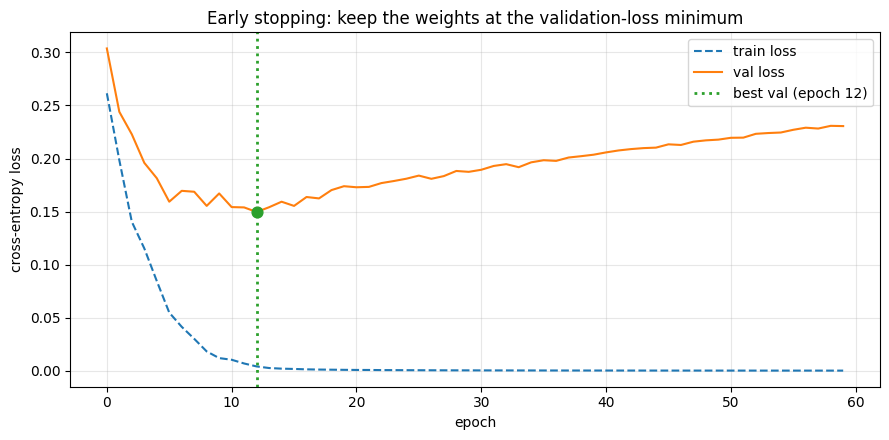

best val loss 0.150 at epoch 12; final val loss 0.231 (worse — overfit past the minimum)


In [6]:
import copy
def train_with_val(epochs=60, patience=8, bs=128):
    model = make_model(); opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossf = nn.CrossEntropyLoss()
    tr_hist, va_hist = [], []; best = (1e9, None, -1)   # (val_loss, weights, epoch)
    for ep in range(epochs):
        perm = torch.randperm(len(Xtr), device=device)
        for i in range(0, len(Xtr), bs):
            ix = perm[i:i+bs]
            opt.zero_grad(); lossf(model(Xtr[ix]), ytr[ix]).backward(); opt.step()
        with torch.no_grad():
            trl = lossf(model(Xtr), ytr).item(); val = lossf(model(Xva), yva).item()
        tr_hist.append(trl); va_hist.append(val)
        if val < best[0]: best = (val, copy.deepcopy(model.state_dict()), ep)
    return tr_hist, va_hist, best

tr_hist, va_hist, best = train_with_val()
stop_ep = best[2] + 8    # patience-limited stop point (illustrative)
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(tr_hist, "--", label="train loss")
ax.plot(va_hist, "-", label="val loss")
ax.axvline(best[2], color="tab:green", ls=":", lw=2, label=f"best val (epoch {best[2]})")
ax.scatter([best[2]], [best[0]], color="tab:green", zorder=5, s=60)
ax.set_title("Early stopping: keep the weights at the validation-loss minimum")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"best val loss {best[0]:.3f} at epoch {best[2]}; final val loss {va_hist[-1]:.3f} (worse — overfit past the minimum)")
assert best[0] < va_hist[-1], (
    f"nothing to early-stop: best val loss {best[0]:.3f} at epoch {best[2]} is not better than "
    f"the final {va_hist[-1]:.3f}")
assert best[2] < len(va_hist) - 1, \
    f"the validation minimum is the last epoch ({best[2]}) - the run never overfit"


**What to notice.** The green marker is the validation-loss minimum — the weights early stopping would keep. Training *past* it (the val curve rising afterward) makes the model strictly **worse** on unseen data, even though train loss keeps dropping. Early stopping captures the best generalization for free — you were going to compute the val curve anyway. It pairs with everything else here: schedules get you to a good minimum faster, regularizers lower the whole val curve, and early stopping grabs its lowest point.

## 5. What you built / learned
- **LR schedules** (step / cosine / warmup+cosine) and why annealing beats a constant LR — plus why big models *need* warmup.
- **Label smoothing**: soft targets that stop overconfidence and improve calibration.
- **Gradient clipping**: caps update magnitude to absorb spikes — essential for RNNs/transformers.
- **Early stopping**: snapshot the validation minimum, the simplest reliable regularizer.

Together with dropout + weight decay (NB6) and the optimizers (NB4), this is the full toolbox that turns "a model that should work" into "a model that does." Every technique here is used, essentially unchanged, to train modern LLMs.

## 6. Exercises
1. **Schedule + accuracy.** Sweep base LR × {constant, cosine, warmup+cosine} and tabulate final val accuracy. Which schedule is most forgiving of a too-high base LR?
2. **Warmup length.** Vary warmup from 0 to 300 steps at a very high base LR. Where does training go from diverging to stable?
3. **Smoothing strength.** Sweep $\varepsilon \in \{0, 0.05, 0.1, 0.3\}$; plot val accuracy and a calibration (reliability) curve.
4. **Clip threshold.** Sweep $\tau \in \{0.1, 1, 10, \infty\}$ at high LR. Too-small clipping hurts too — why?
5. **One-cycle policy.** Implement the "1-cycle" LR schedule (ramp up then down within a single cycle) and compare.
6. **Combine everything.** Build one "well-tuned" recipe (warmup+cosine, label smoothing, clipping, early stopping, dropout, weight decay) vs a naive baseline. Quantify the total gap.

## 7. Interview / residency framing
- *"Why warmup?"* → adaptive optimizers have noisy variance estimates early (bias-correction warm-up); big LR/model can diverge in the first steps; ramping up avoids it. Standard for transformers.
- *"Why cosine decay?"* → anneal LR to settle into the minimum; smooth, no hand-tuned milestones; the modern default.
- *"What does label smoothing do?"* → soft targets ($1-\varepsilon$ on truth) prevent logits→∞ overconfidence; better calibration and slight accuracy gain.
- *"Gradient clipping?"* → rescale gradient to a max norm; same direction, capped magnitude; absorbs spikes; essential for RNNs/transformers.
- *"Early stopping?"* → keep weights at the val-loss minimum; training longer overfits; simplest reliable regularizer.

---
**Next (Tier 2):** *Notebook 10 — Attention from scratch*: scaled dot-product → multi-head attention, causal masking, and positional encodings — the mechanism that replaced recurrence and powers every modern LLM.


## 📚 References & papers

This notebook reproduces / builds on:

- **When Does Label Smoothing Help?** — Müller, Kornblith & Hinton (2019), arXiv:1906.02629.
- **SGDR: Stochastic Gradient Descent with Warm Restarts (cosine schedule)** — Loshchilov & Hutter (2016), arXiv:1608.03983.
- **On the difficulty of training RNNs (gradient clipping)** — Pascanu, Mikolov & Bengio (2013), arXiv:1211.5063.
- **Accurate, Large Minibatch SGD (warmup)** — Goyal et al. (2017), arXiv:1706.02677.